In [3]:
# ============================================
# Customer Retention & Repeat Purchase Analysis
# Python EDA — Mohd Imran
# Dataset: Olist Brazilian E-Commerce
# ============================================

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

print("All libraries loaded successfully")
print("Python EDA is ready to begin")

All libraries loaded successfully
Python EDA is ready to begin


In [6]:
# ============================================
# Load All CSV Files
# ============================================

import os

# Set the path to your data folder
# CHANGE THIS PATH to match where your files are saved
data_path = r"C:\Users\PC\Downloads\project2-python-eda\data"

# Load each CSV file
rfm = pd.read_csv(os.path.join(data_path, 'rfm_summary.csv'))
clv = pd.read_csv(os.path.join(data_path, 'clv_by_segment.csv'))
cohort = pd.read_csv(os.path.join(data_path, 'cohort_data_v2.csv'))
time_return = pd.read_csv(os.path.join(data_path, 'time_to_return.csv'))
review = pd.read_csv(os.path.join(data_path, 'review_repeat.csv'))
category = pd.read_csv(os.path.join(data_path, 'category_repeat.csv'))
kpi = pd.read_csv(os.path.join(data_path, 'kpi_summary.csv'))

# Confirm all files loaded correctly
print("Files loaded successfully")
print(f"RFM Segments:     {rfm.shape[0]} rows, {rfm.shape[1]} columns")
print(f"CLV by Segment:   {clv.shape[0]} rows, {clv.shape[1]} columns")
print(f"Cohort Data:      {cohort.shape[0]} rows, {cohort.shape[1]} columns")
print(f"Time to Return:   {time_return.shape[0]} rows, {time_return.shape[1]} columns")
print(f"Review vs Repeat: {review.shape[0]} rows, {review.shape[1]} columns")
print(f"Category Repeat:  {category.shape[0]} rows, {category.shape[1]} columns")
print(f"KPI Summary:      {kpi.shape[0]} rows, {kpi.shape[1]} columns")

Files loaded successfully
RFM Segments:     9 rows, 7 columns
CLV by Segment:   9 rows, 8 columns
Cohort Data:      161 rows, 5 columns
Time to Return:   4 rows, 3 columns
Review vs Repeat: 5 rows, 5 columns
Category Repeat:  15 rows, 4 columns
KPI Summary:      1 rows, 9 columns


In [7]:
# ============================================
# Business KPI Summary
# ============================================

print("=" * 55)
print("   OLIST CUSTOMER RETENTION — KEY METRICS")
print("=" * 55)

print(f"\n Total Customers Analyzed : {int(kpi['total_customers'][0]):,}")
print(f" Repeat Customers         : {int(kpi['repeat_customers'][0]):,}")
print(f" Single Purchase          : {int(kpi['single_purchase_customers'][0]):,}")
print(f" Repeat Purchase Rate     : {kpi['repeat_rate_pct'][0]}%")
print(f" Average Customer LTV     : ${kpi['avg_customer_ltv'][0]:.2f}")
print(f" Average Order Value      : ${kpi['avg_order_value'][0]:.2f}")
print(f" Total Revenue            : ${kpi['total_revenue'][0]:,.2f}")
print(f" Avg Days Since Purchase  : {int(kpi['avg_days_since_purchase'][0])} days")
print(f" Max Orders by 1 Customer : {int(kpi['max_orders_one_customer'][0])}")

print("\n" + "=" * 55)
print(" Industry Benchmark Repeat Rate : 20% to 30%")
print(f" Olist Repeat Rate              : {kpi['repeat_rate_pct'][0]}%")
print(f" Gap from Benchmark             : {30 - kpi['repeat_rate_pct'][0]:.1f} percentage points below")
print("=" * 55)

   OLIST CUSTOMER RETENTION — KEY METRICS

 Total Customers Analyzed : 93,104
 Repeat Customers         : 2,789
 Single Purchase          : 90,315
 Repeat Purchase Rate     : 3.0%
 Average Customer LTV     : $165.15
 Average Order Value      : $157.61
 Total Revenue            : $15,375,875.44
 Avg Days Since Purchase  : 239 days
 Max Orders by 1 Customer : 15

 Industry Benchmark Repeat Rate : 20% to 30%
 Olist Repeat Rate              : 3.0%
 Gap from Benchmark             : 27.0 percentage points below


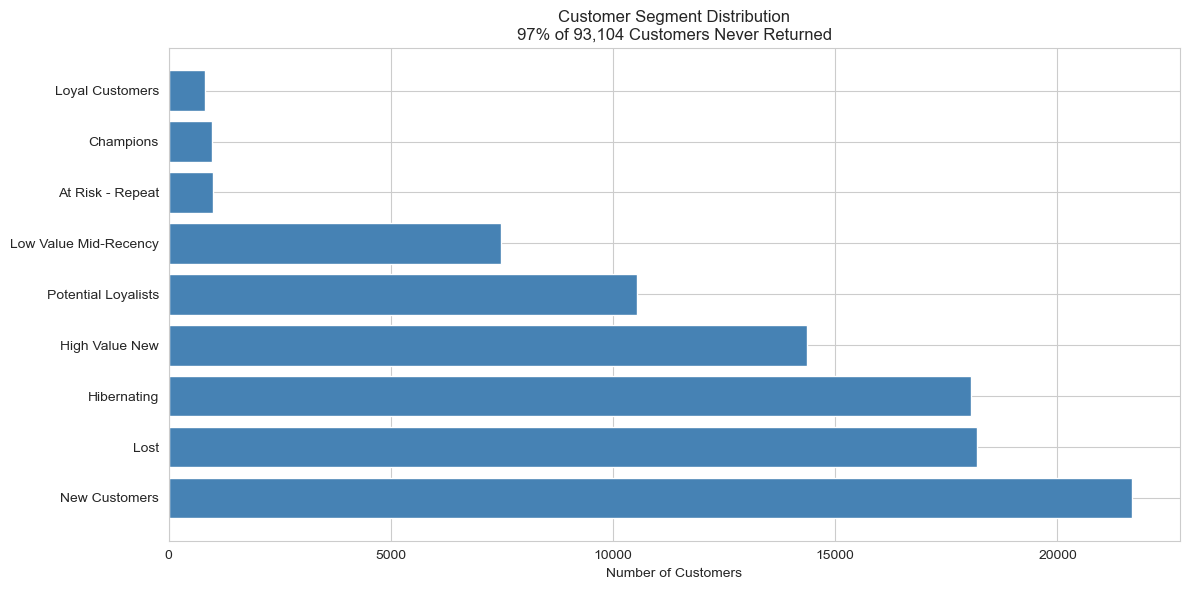

Chart 1 done


In [8]:
# ============================================
# Chart 1 — Customer Segments
# Question: Where do our customers sit?
# ============================================

rfm_sorted = rfm.sort_values('customer_count', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(rfm_sorted['customer_segment'], 
         rfm_sorted['customer_count'],
         color='steelblue')
plt.xlabel('Number of Customers')
plt.title('Customer Segment Distribution\n'
          '97% of 93,104 Customers Never Returned')
plt.tight_layout()
plt.savefig('chart1_segments.png', dpi=150)
plt.show()
print("Chart 1 done")

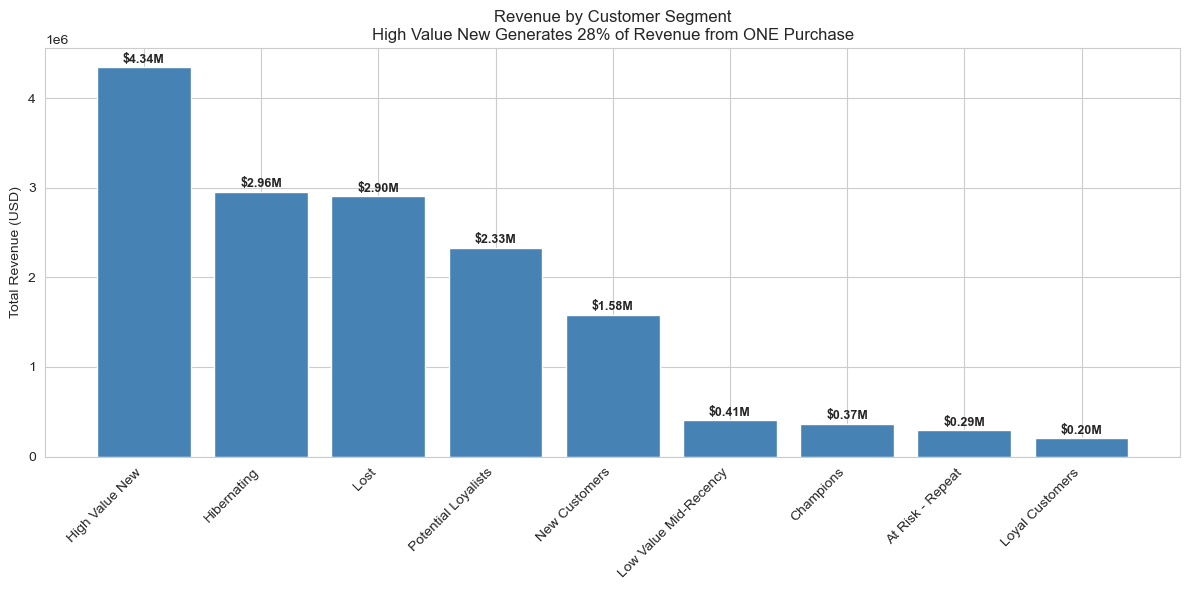

Chart 2 done


In [9]:
# ============================================
# Chart 2 — Revenue by Segment
# Question: Which segments drive the most revenue?
# ============================================

clv_sorted = clv.sort_values('total_segment_revenue', 
                              ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(clv_sorted['customer_segment'],
               clv_sorted['total_segment_revenue'],
               color='steelblue')

# Add value labels on top of each bar
for bar, val in zip(bars, clv_sorted['total_segment_revenue']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50000,
             f'${val/1e6:.2f}M',
             ha='center',
             fontsize=9,
             fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Revenue (USD)')
plt.title('Revenue by Customer Segment\n'
          'High Value New Generates 28% of Revenue from ONE Purchase')
plt.tight_layout()
plt.savefig('chart2_revenue_by_segment.png', dpi=150)
plt.show()
print("Chart 2 done")

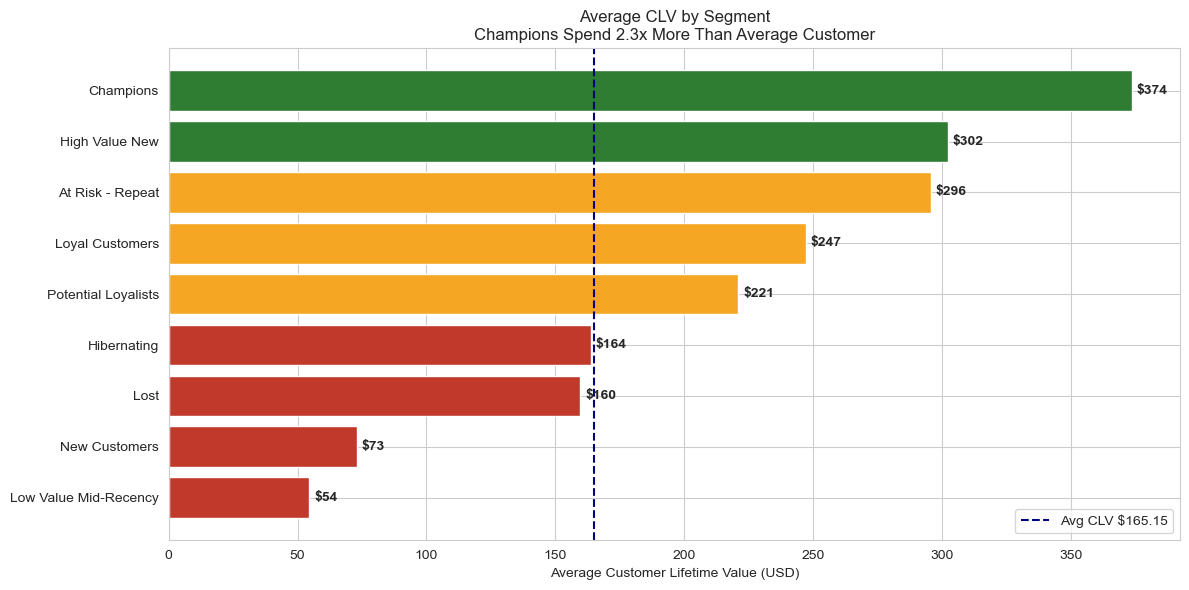

Chart 3 done


In [11]:
# ============================================
# Chart 3 — Average CLV by Segment
# Question: Which customer type is most valuable 
# per person?
# ============================================

clv_sorted2 = clv.sort_values('avg_clv', ascending=True)

colors = ['#C0392B' if x < 200 else 
          '#F5A623' if x < 300 else 
          '#2E7D32' 
          for x in clv_sorted2['avg_clv']]

plt.figure(figsize=(12, 6))
bars = plt.barh(clv_sorted2['customer_segment'],
                clv_sorted2['avg_clv'],
                color=colors)

# Add value labels
for bar, val in zip(bars, clv_sorted2['avg_clv']):
    plt.text(bar.get_width() + 2,
             bar.get_y() + bar.get_height()/2,
             f'${val:.0f}',
             va='center',
             fontsize=10,
             fontweight='bold')

plt.axvline(x=165.15, color='navy', linestyle='--', 
            linewidth=1.5, label='Avg CLV $165.15')
plt.xlabel('Average Customer Lifetime Value (USD)')
plt.title('Average CLV by Segment\n'
          'Champions Spend 2.3x More Than Average Customer')
plt.legend()
plt.tight_layout()
plt.savefig('chart3_clv_comparison.png', dpi=150)
plt.show()
print("Chart 3 done")

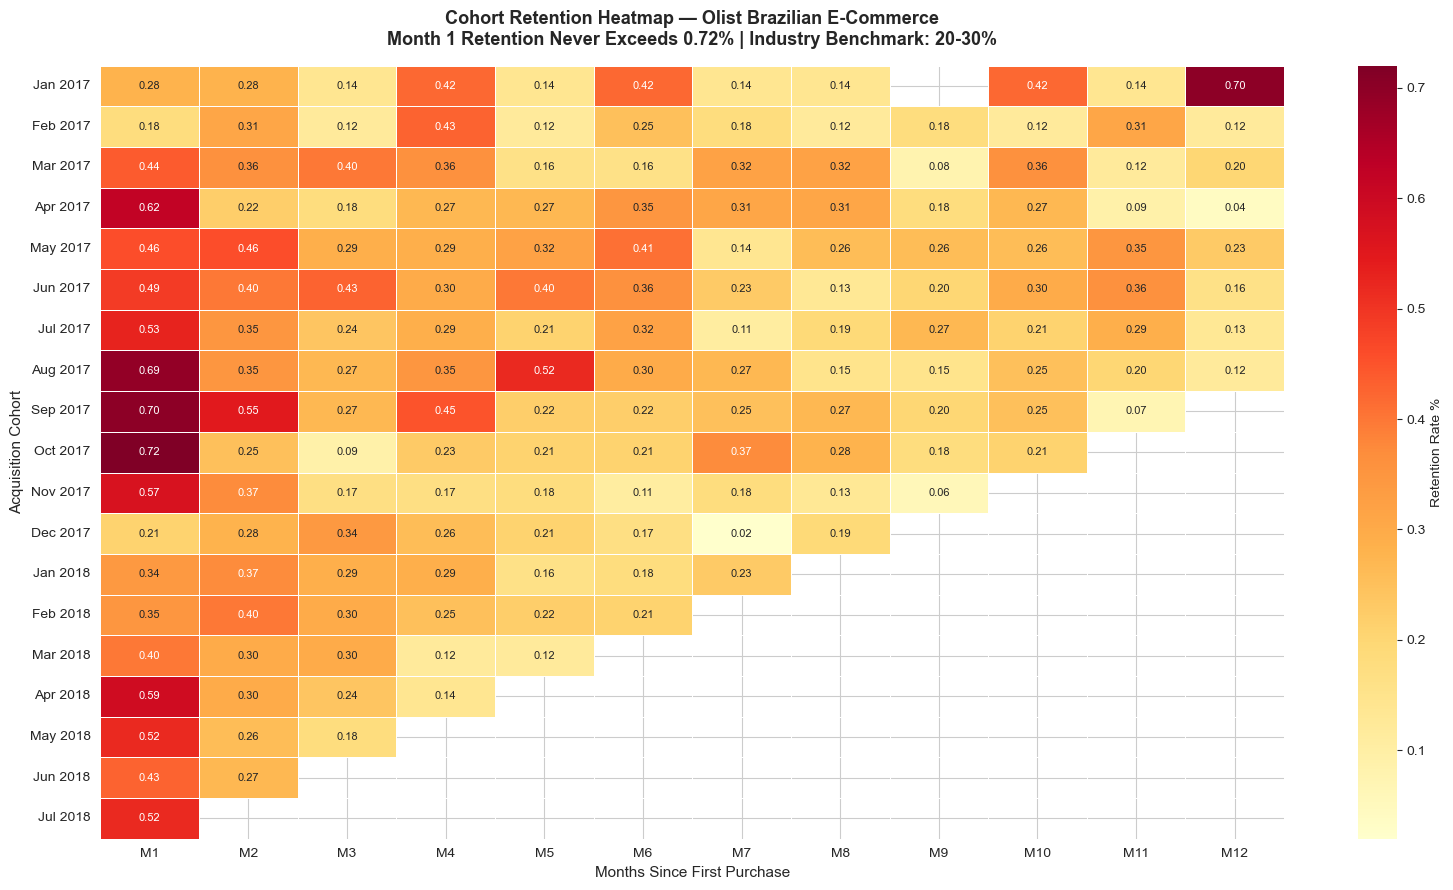

Chart 4 done


In [13]:
# ============================================
# Chart 4 — Cohort Retention Heatmap
# Question: Do customers come back month after month?
# ============================================

# Pivot the cohort data into matrix format
cohort_pivot = cohort.pivot_table(
    index='cohort',
    columns='month_label',
    values='retention_rate_pct'
)

# Sort cohorts chronologically using cohort_sort
cohort_order = cohort.drop_duplicates('cohort')\
                     .sort_values('cohort_sort')['cohort'].tolist()
cohort_pivot = cohort_pivot.reindex(cohort_order)

# Sort columns M1 to M12
col_order = [f'M{i}' for i in range(1, 13) 
             if f'M{i}' in cohort_pivot.columns]
cohort_pivot = cohort_pivot[col_order]

# Draw heatmap
plt.figure(figsize=(16, 9))
sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Retention Rate %'},
    annot_kws={'size': 8}
)

plt.title('Cohort Retention Heatmap — Olist Brazilian E-Commerce\n'
          'Month 1 Retention Never Exceeds 0.72% | '
          'Industry Benchmark: 20-30%',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Months Since First Purchase', fontsize=11)
plt.ylabel('Acquisition Cohort', fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('chart4_cohort_heatmap.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Chart 4 done")

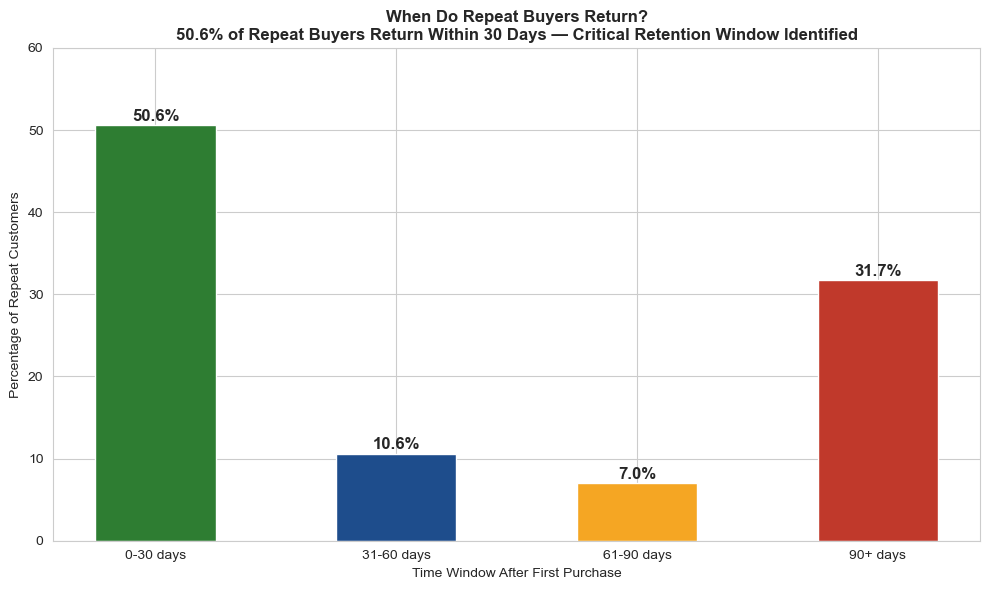

Chart 5 done


In [15]:
# ============================================
# Chart 5 — Time to Second Purchase
# Question: When do repeat buyers return?
# ============================================

# Define order and colors
window_order = ['0-30 days', '31-60 days', 
                '61-90 days', '90+ days']
time_return['return_window'] = pd.Categorical(
    time_return['return_window'],
    categories=window_order,
    ordered=True
)
time_return = time_return.sort_values('return_window')

colors = ['#2E7D32', '#1E4D8C', '#F5A623', '#C0392B']

plt.figure(figsize=(10, 6))
bars = plt.bar(time_return['return_window'],
               time_return['pct_of_repeat_customers'],
               color=colors,
               width=0.5)

# Add percentage labels on top
for bar, val in zip(bars, 
                    time_return['pct_of_repeat_customers']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%',
             ha='center',
             fontsize=12,
             fontweight='bold')

plt.ylabel('Percentage of Repeat Customers')
plt.xlabel('Time Window After First Purchase')
plt.title('When Do Repeat Buyers Return?\n'
          '50.6% of Repeat Buyers Return Within 30 Days — '
          'Critical Retention Window Identified',
          fontsize=12, fontweight='bold')
plt.ylim(0, 60)
plt.tight_layout()
plt.savefig('chart5_time_to_return.png', dpi=150)
plt.show()
print("Chart 5 done")

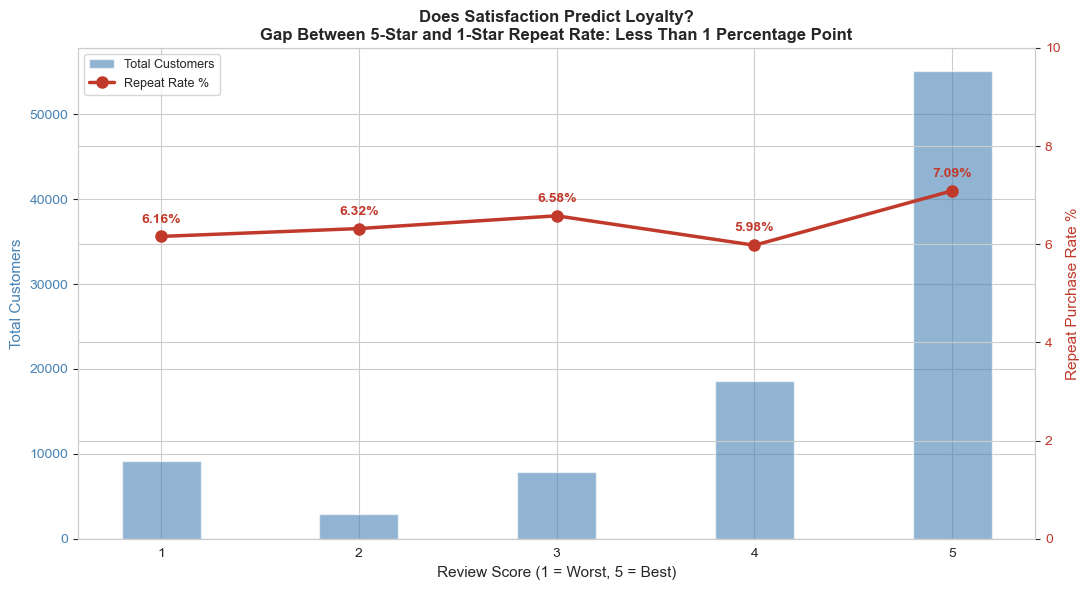

Chart 6 done


In [17]:
# ============================================
# Chart 6 — Review Score vs Repeat Rate
# Question: Does customer satisfaction predict 
# repeat purchase?
# ============================================

fig, ax1 = plt.subplots(figsize=(11, 6))

# Bar chart — total customers per review score
ax1.bar(review['review_score'],
        review['total_customers'],
        color='steelblue',
        alpha=0.6,
        width=0.4,
        label='Total Customers')
ax1.set_xlabel('Review Score (1 = Worst, 5 = Best)',
               fontsize=11)
ax1.set_ylabel('Total Customers', color='steelblue',
               fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line chart — repeat rate on second axis
ax2 = ax1.twinx()
ax2.plot(review['review_score'],
         review['repeat_rate_pct'],
         color='#C0392B',
         marker='o',
         linewidth=2.5,
         markersize=8,
         label='Repeat Rate %')
ax2.set_ylabel('Repeat Purchase Rate %',
               color='#C0392B', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#C0392B')
ax2.set_ylim(0, 10)

# Add repeat rate labels
for x, y in zip(review['review_score'],
                review['repeat_rate_pct']):
    ax2.annotate(f'{y}%',
                 xy=(x, y),
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center',
                 fontsize=10,
                 fontweight='bold',
                 color='#C0392B')

plt.title('Does Satisfaction Predict Loyalty?\n'
          'Gap Between 5-Star and 1-Star Repeat Rate: '
          'Less Than 1 Percentage Point',
          fontsize=12, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('chart6_review_vs_repeat.png', dpi=150)
plt.show()
print("Chart 6 done")

In [1]:
# ============================================
# FINAL CELL: Project Summary
# ============================================

print("=" * 60)
print("   CUSTOMER RETENTION EDA — KEY FINDINGS SUMMARY")
print("=" * 60)

print("""
FINDING 1 — RETENTION CRISIS
- Only 3% of 93,104 customers made a repeat purchase
- Industry benchmark: 20-30%
- Gap: 27 percentage points below benchmark

FINDING 2 — HIGH VALUE OPPORTUNITY  
- 14,370 High Value New customers spent $302 average
- They generate 28.24% of total revenue from ONE purchase
- Converting 10% to repeat = $433,774 additional revenue

FINDING 3 — CRITICAL RETENTION WINDOW
- 50.6% of repeat buyers return within 30 days
- Day 7-14 post-delivery = optimal re-engagement window
- After 30 days probability of return drops sharply

FINDING 4 — COHORT COLLAPSE
- Month 1 retention never exceeds 0.72% across 20 cohorts
- October 2017: best cohort at 0.72%
- December 2017: worst cohort at 0.21% (holiday buyers)

FINDING 5 — SATISFACTION PARADOX
- 5-star customers repeat at 7.09%
- 1-star customers repeat at 6.16%
- Gap: less than 1% — satisfaction barely predicts loyalty
- Platform convenience drives return more than satisfaction

BUSINESS PRIORITY:
- Launch 7-day post-purchase re-engagement campaign
- Target: High Value New segment (14,370 customers)
- Estimated annual recovery: $433,774 at 10% conversion
""")

print("=" * 60)
print("Tools: Python, Pandas, Matplotlib, Seaborn")
print("Data:  Olist Brazilian E-Commerce Dataset")
print("By:    Mohd Imran")
print("=" * 60)

   CUSTOMER RETENTION EDA — KEY FINDINGS SUMMARY

FINDING 1 — RETENTION CRISIS
- Only 3% of 93,104 customers made a repeat purchase
- Industry benchmark: 20-30%
- Gap: 27 percentage points below benchmark

FINDING 2 — HIGH VALUE OPPORTUNITY  
- 14,370 High Value New customers spent $302 average
- They generate 28.24% of total revenue from ONE purchase
- Converting 10% to repeat = $433,774 additional revenue

FINDING 3 — CRITICAL RETENTION WINDOW
- 50.6% of repeat buyers return within 30 days
- Day 7-14 post-delivery = optimal re-engagement window
- After 30 days probability of return drops sharply

FINDING 4 — COHORT COLLAPSE
- Month 1 retention never exceeds 0.72% across 20 cohorts
- October 2017: best cohort at 0.72%
- December 2017: worst cohort at 0.21% (holiday buyers)

FINDING 5 — SATISFACTION PARADOX
- 5-star customers repeat at 7.09%
- 1-star customers repeat at 6.16%
- Gap: less than 1% — satisfaction barely predicts loyalty
- Platform convenience drives return more than satis